In [9]:
import torch
import numpy as np
from copy import deepcopy
import pickle as pkl

from torch import nn
from umap import UMAP

from run_sim import Config, run_sim, run_sim_wrapper, create_data
from utils import *
from utils_plot import *
from tqdm import tqdm
from utils import *
from functools import reduce
import os
from joblib import Parallel, delayed
import shutil

# http://localhost:8080/tree?token=98ea3fcb0b09366b2803c421736080a9ed9f4ca179479adf

In [10]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [11]:
C = Config()

C.G = 0.6
C.sig_h_2 = None
C.linear_net = False
C.learning_rate = 0.00001
C.L=5
C.print_progress = True
C.length_corridors = [20]*1
C.max_move = 10
C.hidden_size = 250 # (C.length_corridors[0]+2*C.max_move+1 + 1)*len(C.length_corridors)
C.num_epochs = 10000
C.algo_name = 'Adam'
C.loss_fn = nn.MSELoss()
C.one_hot_outputs = False
C.output_size = 100


var_name = 'output_size'
var_values = np.linspace(20, 100, 10).astype(int)

In [ ]:
num_gpus = 8

# Ensure the results directory exists
results_dir = f'results/notebook_results/linear/{var_name}'
if os.path.exists(results_dir):
    shutil.rmtree(results_dir)
os.makedirs(results_dir, exist_ok=True)

def run_and_save(var_value, index):
    C_local = deepcopy(C)
    setattr(C_local, var_name, var_value)
    if var_name == 'L':
        C_local.learning_rate = C.learning_rate * 0.2**C_local.L
    C_local.gpu_id = index % num_gpus
    data_dict = run_sim_wrapper(C_local)
    out_path = os.path.join(results_dir, f'data_dict_{getattr(C_local, var_name)}.pkl')
    # Remove 'state_dict_l' and 'hidden_l' from data_dict if they exist
    data_dict.pop('state_dict_l', None)
    data_dict.pop('hidden_l', None)
    with open(out_path, 'wb') as f:
        pkl.dump(data_dict, f)
    return out_path

# Run in parallel
paths = Parallel(n_jobs=-1)(
    delayed(run_and_save)(var_value, index) for index, var_value in enumerate(var_values)
)
# Load all results into data_dict_l
data_dict_l = []
for path in paths:
    with open(path, 'rb') as f:
        data_dict_l.append(pkl.load(f))

for data_dict in data_dict_l:
    print(f'{var_name}: {getattr(data_dict["C"], var_name)} --- X shape: {data_dict["X"].shape} --- Number of hidden: {data_dict["C"].hidden_size}')

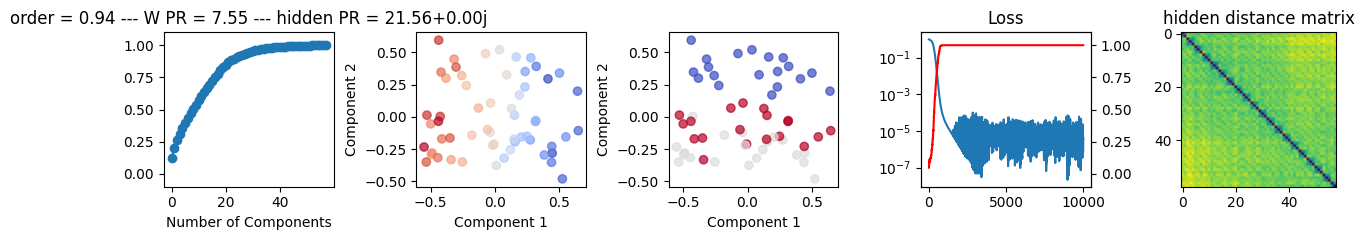

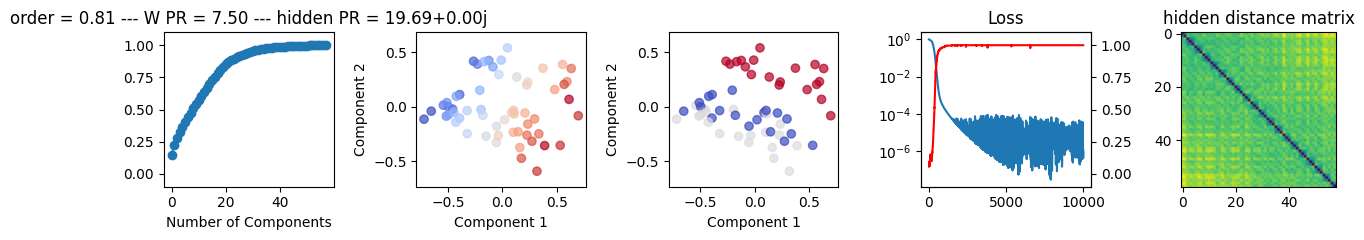

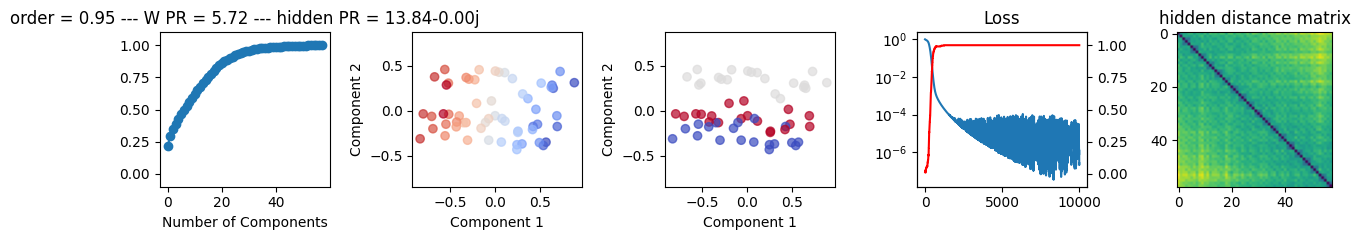

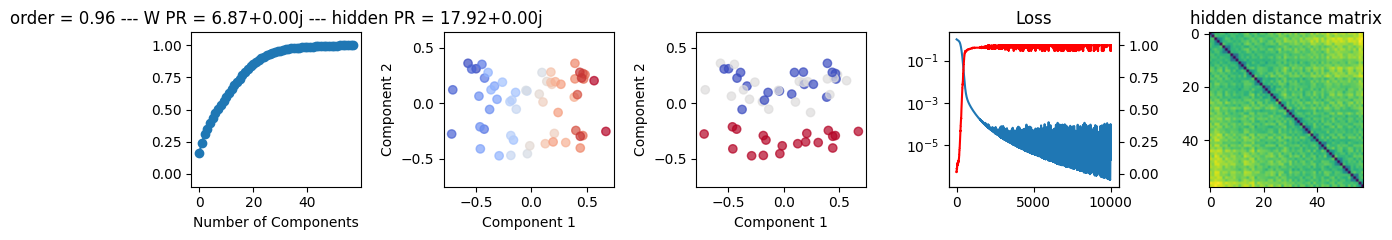

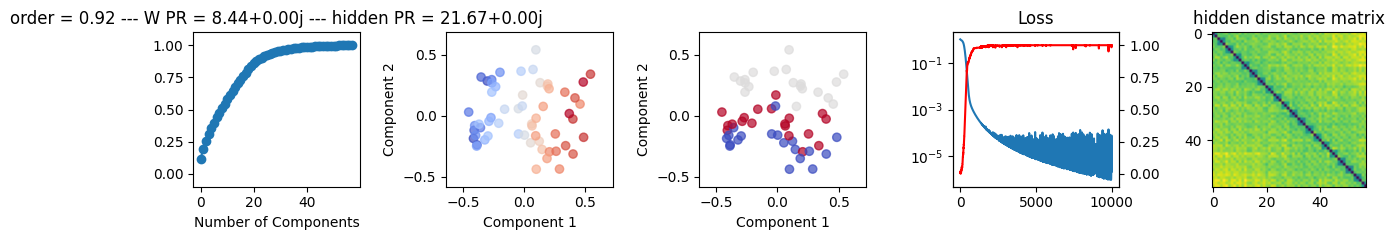

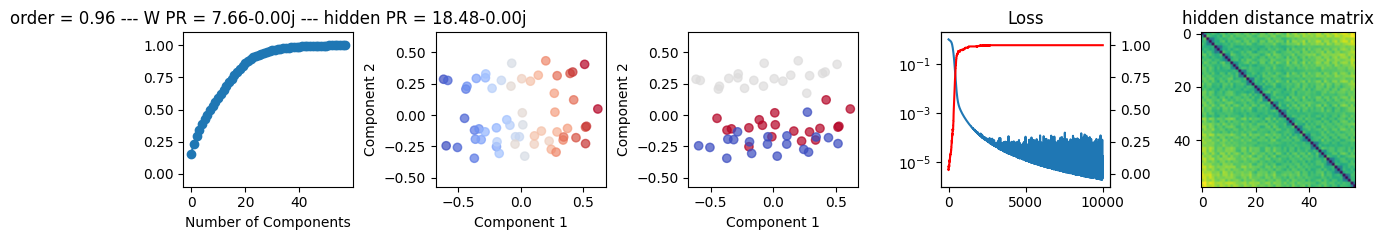

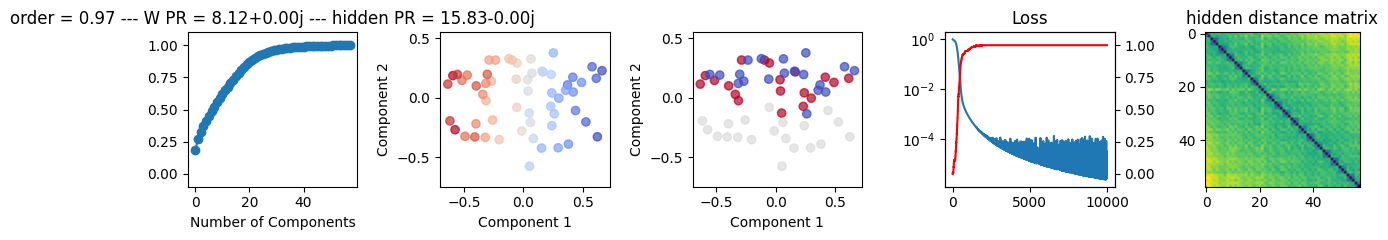

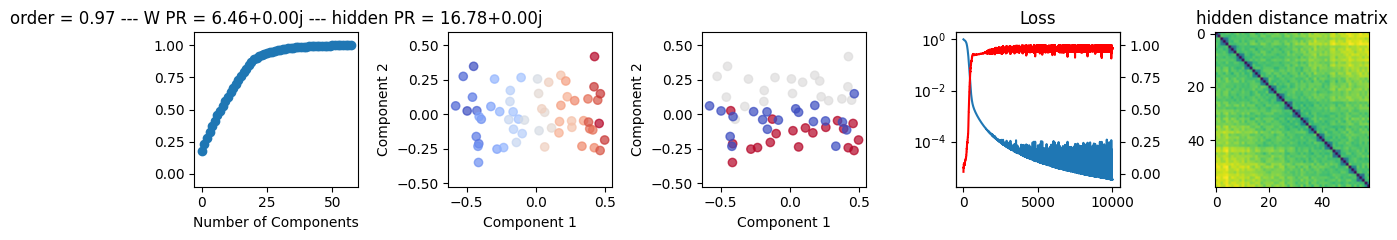

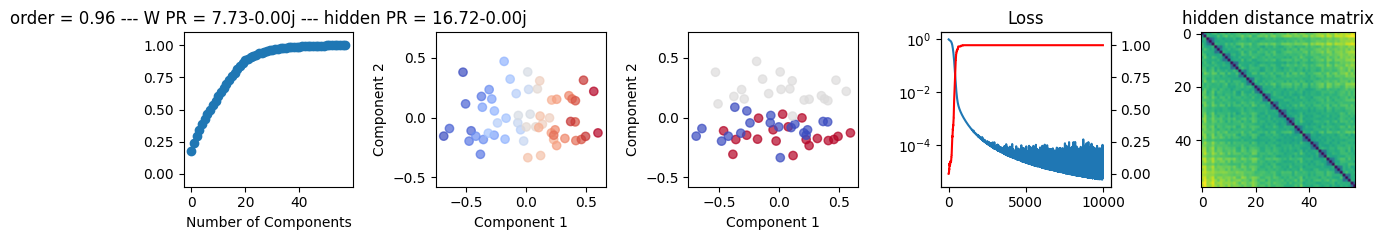

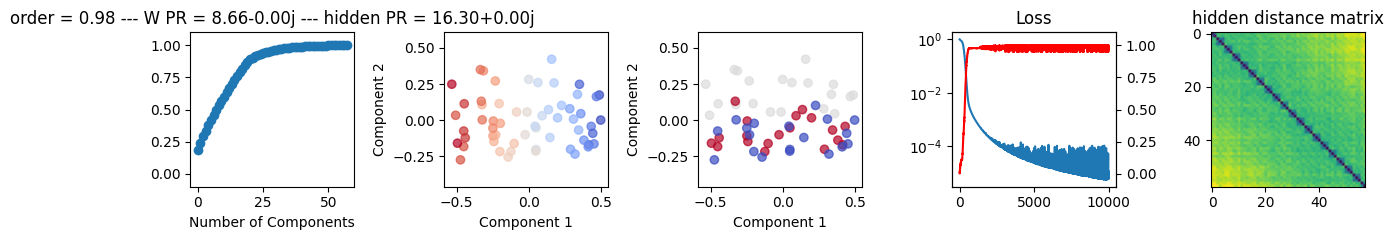

In [ ]:
for data_dict in data_dict_l:
    plot_pca(data_dict)

In [ ]:
# PR_l = []
# order_l = []
# for data_dict in data_dict_l:
#     X = data_dict['X']
#     y = data_dict['y']
#     loc_y = data_dict['loc_y']
#     action_taken = data_dict['action_taken']
#     N = X.shape[0]

#     XT_X = X.T @ X
#     XT_y = X.T @ y
#     OLS = torch.linalg.pinv(XT_X) @ XT_y  

#     U, S, V = np.linalg.svd(OLS, full_matrices=False)
#     hidden = X @ U @ np.diag(S)

#     PR_l.append(np.sum(S**2)**2/np.sum(S**4))
#     order_l.append(get_r_2(hidden[:,:1], loc_y))

# plt.plot(var_values, order_l)
# plt.xlabel('Output Size')
# plt.ylabel('Order')
# ax2 = plt.twinx()
# ax2.plot(var_values, PR_l, c='tab:orange')
# ax2.set_ylabel('PR')
# plt.show()

c:\Users\avivra\Desktop\cursor_projects\RepresentationShaping\.venv\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\avivra\Desktop\cursor_projects\RepresentationShaping\.venv\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


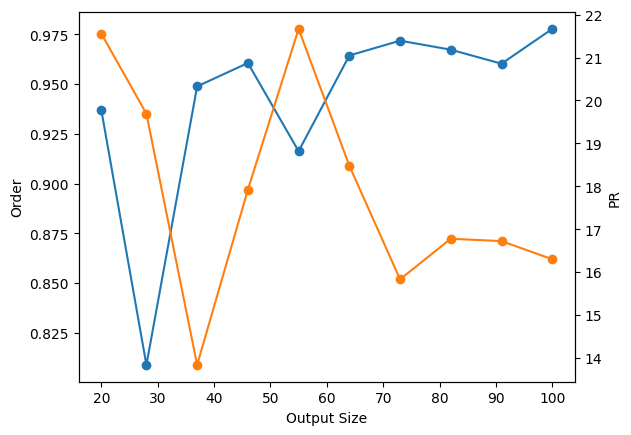

In [ ]:
PR_l = []
order_l = []
for data_dict in data_dict_l:
    action_taken = data_dict['action_taken']
    cond = abs(action_taken) <= 1
    hidden = data_dict['hidden_states'][-1].numpy()[cond]
    loc_y = data_dict['loc_y'][cond]
    hidden_pca = PCA(n_components=1).fit_transform(hidden)

    PR_l.append(calc_PR(hidden))
    order_l.append(get_r_2(hidden_pca[:,:1], loc_y))

plt.plot(var_values, order_l, 'o-')
plt.xlabel('Output Size')
plt.ylabel('Order')
ax2 = plt.twinx()
ax2.plot(var_values, PR_l, 'o-', c='tab:orange')
ax2.set_ylabel('PR')
plt.show()

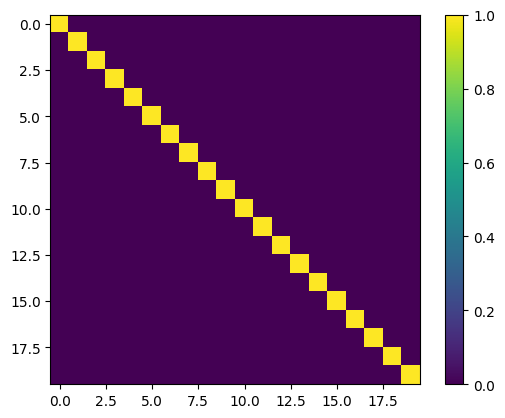

In [ ]:
data_dict = data_dict_l[0]
y = data_dict['y']
loc_y = data_dict['loc_y']
obs = [y[loc_y==l][0].numpy() for l in np.unique(loc_y)]
obs = np.array(obs)
plt.imshow(obs@obs.T/np.linalg.norm(obs, axis=1).mean())
plt.colorbar()
